# Baseline Steel Thread — Isolating the Effect of Interventions on Item Warm-Up

This notebook builds a controlled experiment for measuring how a recommender's ability to
retrieve an item changes as that item accumulates its own interaction history — and it's
built specifically so that later interventions (content embeddings, improved content
embeddings, LLM-simulated interactions) can be added and compared on equal footing.

**The core experimental principle:** hold every source of variation fixed except the one
under study. User preferences are fit once, frozen, and reused identically everywhere in
this notebook — for the baseline pure-CF method here, and for every future method this
experiment gets extended to. Only the *item's* representation is allowed to change as it
gains interaction history. This means an observed change in retrieval quality can be
attributed to "this item gained more signal," not to "the model also happened to relearn
different user preferences this time."

**Dataset:** Amazon Books 5-core, restricted to common users (users who reviewed both Books and
Movies) — see data_filtering.ipynb's "Build the 5-core enriched dataset" section. The full-scale run.

**Runtime:** dual RTX 4090 (WSL2/CUDA). `implicit` does `fit()` + `recalculate_item()` on CPU;
retrieval/top-K (`recommend`) runs on the GPU via `cf.ALSModel.prepare_gpu_recommend` (torch.topk).

**Run:** `python baseline_steel_thread_cf.py` from `notebooks/` (recsys/ and data/ one level up).

---
## Module layout

The pipeline logic itself now lives in four importable modules, not in this notebook:

- **`load.py`** — load the Amazon Books reviews, ID remapping, the cold/warm split, and the
  warm-item reference train/test split. Returns one `Dataset` object.
- **`protocol.py`** — `RetrievalModel`, the structural contract (`fit`/`recommend`/`fold_in`)
  every retrieval method below satisfies, so `eval.py` never branches on model type.
- **`pop.py`** — `PopularityModel` (Section 5a) and `ActivityModel`, its Mode-B dual.
- **`cf.py`** — `ALSModel` (Section 5b), wrapping `implicit`'s ALS.
- **`eval.py`** — every metric function, the within-item ceiling reference, and both warm-up
  sweeps (Mode A: user-centric via `sweep_mode_a_cached`; Mode B: item-to-user via
  `sweep_item_to_user_gpu`) — one call per method, no hand-written per-model loop.

A future intervention (a content-based hybrid method, say) becomes a new module implementing
`RetrievalModel` — plugging into `eval.py` with no changes to `eval.py` itself.

### Note on the `implicit` API
This notebook targets **`implicit` 0.7.x**. `model.fit()`, `ndcg_at_k()`, and
`model.recommend()` all expect a **user × item** matrix; we build and use one consistently
throughout. `AlternatingLeastSquares.recalculate_item(itemid, item_users)` is the one
exception — it expects **item × user** orientation. This is handled once, inside
`Dataset.revealed_item_users_at_k()` and `cf.ALSModel.fold_in()`, rather than at every call
site as before.

## 0. Environment & imports

In [ ]:
%%time
import platform
import sys
import time

sys.path.insert(0, "..")  # notebook lives in notebooks/; the recsys/ package is one level up

import numpy as np
import matplotlib
try:
    get_ipython()            # defined only under IPython/Jupyter -> keep the inline backend
except NameError:
    matplotlib.use("Agg")    # plain `python script.py`: headless, save figures to PNG instead
import matplotlib.pyplot as plt
import implicit
import wandb

from recsys import load
from recsys import pop
from recsys import cf
from recsys import eval as ev

DEVICE = "cuda:1"   # which GPU the recommend/sweeps use. GPU 1 is idle; GPU 0 is shared with the
                    # desktop (and gets starved). ALS fit() is CPU-only regardless (no GPU implicit).

print(f"python     {platform.python_version()}  ({platform.machine()})")
print(f"implicit   {implicit.__version__}")

# Weights & Biases (W&B) -- experiment tracking for the warm-up sweeps (Sections 9-10).
WANDB_ENTITY_NAME = "mads-team-cold-start"
WANDB_PROJECT_NAME = "llm-cold-start-recsys"
RUN_TAG = time.strftime("%Y%m%d-%H%M%S")

WANDB_ENABLED = False  # flip to True to actually upload runs to W&B (off by default; disabled = no-op)
WANDB_MODE = "online" if WANDB_ENABLED else "disabled"

/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/freya/miniforge3/envs/699-gpu/lib/python3.12/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


python     3.12.13  (x86_64)
implicit   0.7.3
CPU times: user 1.73 s, sys: 1.04 s, total: 2.77 s
Wall time: 971 ms


## 1-4. Load Amazon Books, build the cold/warm split

See `load.py` for the full mechanism (ID remapping, sparse matrix construction, the cold-item
eligibility filter and reveal/reserve split, and the warm-item reference split). Briefly:

- A fixed 10% of items with at least 25 total interactions are selected as structurally
  "cold" (`load.load_dataset`'s defaults: `min_interactions=25`, `cold_item_fraction=0.10`).
- Each cold item's first 20 interactions (chronologically) form its revealable history —
  `Dataset.revealed_matrix_at_k(k)`/`revealed_item_users_at_k(k)` expose exactly the first
  `k` of these; everything after is permanently reserved for evaluation (`Dataset.test_matrix`).
- A per-user leave-last-out (LOO) split on the warm (non-cold) items gives `Dataset.ref_train`/
  `ref_val`/`ref_test` — each user's last warm interaction is held out for test, the second-last
  for val, the rest for train. Every model in this notebook fits on `ref_train`, so no model has
  ever seen a single cold-item interaction.

In [2]:
%%time
# Pickle cache for static, expensive-to-rebuild results (the Dataset; the Popularity floor).
# cache_pickle keys each file by name + a short hash of `params` (K, K_LEVELS, ...), so changing a
# parameter automatically uses a fresh cache file instead of a stale one. It does NOT track recsys
# code changes -- if you edit load.py's split or an eval.py metric, clear data/cache/ by hand.
import os
import pickle
import hashlib


def cache_pickle(name, compute, params=None):
    tag = "" if params is None else "_" + hashlib.md5(repr(params).encode()).hexdigest()[:8]
    path = f"../data/cache/{name}{tag}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    val = compute()
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(val, f, protocol=pickle.HIGHEST_PROTOCOL)
    return val


# Dataset: unkeyed (params=None -> books_5core_dataset.pkl). Cache key renamed from "books_dataset"
# on the 5-core swap so it can't collide with the old common-user cache -- the pickle is keyed by
# params/name, NOT by data_path, so a rename (or hand-deleting the pkl) is required when the data
# changes. Its only inputs are the fixed parquet + load.py's split defaults; clear it by hand if
# load.py changes.
dataset = cache_pickle("books_5core_dataset", lambda: load.load_dataset(
    data_path="../data/filtered/books_5core_common.parquet"))

N_REVEAL = 20
K_LEVELS = list(range(N_REVEAL + 1))  # 0, 1, 2, ..., 20

print(f"users: {dataset.n_users:,}   items: {dataset.n_items:,}")
print(f"cold items: {len(dataset.cold_item_ids)}")
print(f"ref_train non-zeros: {dataset.ref_train.nnz:,}   ref_test non-zeros: {dataset.ref_test.nnz:,}")
print(f"reserved cold-item test interactions: {dataset.test_matrix.nnz:,}")

users: 384,339   items: 487,790
cold items: 2727
ref_train non-zeros: 2,823,200   ref_test non-zeros: 351,851
reserved cold-item test interactions: 13,635
CPU times: user 99.9 ms, sys: 144 ms, total: 244 ms
Wall time: 243 ms


## 5. Two retrieval models — popularity baseline and collaborative filtering

This is the point in the pipeline where different retrieval **methods** are compared, side
by side, against the exact same data — 5a is a no-collaborative-filtering floor, 5b is the
collaborative-filtering method under study today. A future intervention becomes a third
`RetrievalModel` implementation here, not a restructuring of this notebook.

**Both models fit on `dataset.ref_train`** — nothing else, and this matters. It contains only
warm items, so the resulting user representations have never seen a single cold item's
interaction, at any point.

### 5a. Popularity baseline (no collaborative filtering)

Ranks items by raw training-interaction count — the same global list for every user,
personalized only by excluding each user's already-seen items. See `pop.PopularityModel`.

In [3]:
%%time
pop_model = pop.PopularityModel().fit(dataset.ref_train)
print(f"Most popular item (train_index {pop_model.ranked_items[0]}): "
      f"{pop_model.popularity[pop_model.ranked_items[0]]} training interactions")

Most popular item (train_index 441091): 3327 training interactions
CPU times: user 17.6 ms, sys: 21 ms, total: 38.6 ms
Wall time: 37.3 ms


### 5b. Collaborative filtering — ALS

`implicit.als.AlternatingLeastSquares`, wrapped by `cf.ALSModel` to satisfy
`protocol.RetrievalModel`. This fits one ALS model at the real baseline config (below); it is
**reused as seed 0** of Section 6's `N_SEEDS` ensemble (so no fit is wasted) and is also the
example model for Section 8's per-user recommendations. ALS fit is CPU-bound and scales with
factors^2 * iterations; the GPU recommend/sweep are unaffected by raising them.

In [4]:
%%time
# Real config for a fair baseline (Option B: CPU fit -- conda-forge implicit has no GPU build).
# ALS fit() is CPU-bound and scales ~O(nnz * factors^2 * iterations), so at ~5M interactions this
# is SLOW -- expect a long fit per model (N_SEEDS is dropped below to bound total fit time). The
# GPU recommend/sweeps are unaffected by the larger factors.
# Model hyperparameters, declared here because ALS_PARAMS (below) consumes them and is defined
# before Section 6's N_SEEDS. N_ITERATIONS is the ALS training-iteration count; both `model` (5b)
# and the N_SEEDS ensemble (Section 6) fit with these exact params.
N_FACTORS = 64
N_ITERATIONS = 20   # final baseline run (was 15 for dev). More iters -> more converged factors.
ALS_PARAMS = dict(factors=N_FACTORS, regularization=0.01, iterations=N_ITERATIONS)

model = cf.ALSModel(random_state=0, **ALS_PARAMS)   # seed 0 -- reused in the Section 6 ensemble
print("Fitting ALS on the reference training set...")
model.fit(dataset.ref_train)
print("Done.")

Fitting ALS on the reference training set...
Done.
CPU times: user 1min 28s, sys: 2min 29s, total: 3min 57s
Wall time: 24.8 s


## 6. Within-item warm reference (the ceiling)

Computed **ahead of** Section 7's cold-start evaluation, on purpose: reading that result with no
frame of reference tells you little on its own. This is the **within-item ceiling** — each cold
item folded in with ALL of its pre-test interactions (`dataset.ceiling_pool`, everything but its
last 5), evaluated on the **same last-5 reserved test** the warm-up curve uses. It's the curve's
own asymptote: the same items, at their fully-warm state, on the same test. This deliberately
**replaces** the old cross-population "warm items on `ref_test`" reference, which compared the cold
set (>=25 interactions) against the >=5-interaction warm bulk — a degree mismatch that made the
reference an unfair, lower bar (see the evaluation-methodology discussion / `citations.md` §3:
MetaEmb/MWUF within-item warm-up; Steck 2011 popularity-stratified evaluation).

**Why `N_SEEDS` independent fits.** ALS's factor initialization is random, so a single fit is
one sample from a distribution of outcomes. Refitting `N_SEEDS` times and reporting mean ±
spread gives an honest picture of signal vs. initialization noise. These same fits are reused,
unchanged, for Section 9's warm-up curve.

**Metrics & pools.** Top-K (NDCG/Precision/Recall/HitRate@K) is the headline, over the full
warm_cold candidate pool. AUC is reported **last and secondary**, over the **degree-matched pool**
(warm items with `ref_train` degree >= 25, plus cold) — because AUC is the one metric the cold-vs-
warm degree gap distorts (a partially-revealed cold item can out-rank the low-degree warm tail on
raw count without ever entering a top-K). Degree-matching is reserved for AUC; top-K is left on the
full pool, where the popularity artifact self-mutes. **Why K=100:** retrieval-stage cutoff — a cold
item competes against ~247k warm items, so a strict top-10 is hopeless; K=100 asks "did it surface
into the candidate pool at all."

In [5]:
%%time
K = 100
N_SEEDS = 10     # final baseline run: 10 independent fits for a stable mean +/- spread (was 3 for dev)
METRICS = ev.METRICS  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]
RUN_POP = True   # Popularity floor. recommend() is vectorized, and pop_ref / pop_k0 / pop_curve are
                 # pickle-cached below (via cache_pickle) -- Popularity is deterministic and the
                 # Dataset is fixed, so they're computed once and loaded thereafter. Delete
                 # data/cache/pop_*.pkl to rebuild (e.g. if K, K_LEVELS, or the Dataset change).

# Reuse the 5b fit as seed 0, then fit the remaining N_SEEDS-1 seeds -- one fit per seed, none wasted.
seed_models = [model] + [cf.ALSModel(random_state=seed, **ALS_PARAMS).fit(dataset.ref_train)
                         for seed in range(1, N_SEEDS)]
print(f"Ensemble of {N_SEEDS} independent ALS fits on the reference training set "
      f"(seeds 0-{N_SEEDS - 1}; seed 0 is the model fit in 5b).")

# Move recommend()/top-K to the GPU for every ALS model (fit + recalculate_item stay on implicit/CPU).
# candidates="warm_cold" scores the trained warm items + the cold items under study (not the ~2.4M
# untrained sparse items) -- this is what makes the warm-up sweep tractable at Amazon-Books scale.
for m in seed_models:   # seed 0 == `model`, so this prepares it too (no double-prepare)
    m.prepare_gpu_recommend(dataset, candidates="warm_cold", device=DEVICE)
print("ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).")

# Within-item warm reference: each cold item folded in with ALL its pre-test interactions
# (dataset.ceiling_pool -- everything but its last 5), evaluated on the SAME last-5 reserved test the
# warm-up curve uses. Replaces the old cross-population "warm items on ref_test" line: this is the
# curve's OWN asymptote on the SAME items and SAME test, so it's degree-matched by construction (no
# comparing cold >=25-degree items to the >=5 warm bulk). Top-K uses the full warm_cold pool; AUC uses
# the degree-matched pool (warm degree >= 25 + cold) that prepare_gpu_recommend built above.
def _pop_ref():
    r = ev.ceiling_reference([pop_model], dataset, K=K)            # top-K ceiling; Popularity AUC left NaN here
    r["mean"]["AUC"] = ev.pop_ceiling_auc(pop_model.fold_in_ceiling(dataset), dataset, seed_models[0])
    r["std"]["AUC"] = 0.0
    return r
pop_ref = cache_pickle("pop_ref", _pop_ref, params=(K, "auc", "5core")) if RUN_POP else None  # markers: "auc" ignores pre-AUC files, "5core" ignores common-user-dataset files
als_ref = ev.ceiling_reference(seed_models, dataset, K=K)

print(f"\nWithin-item warm reference (each cold item folded in with all its pre-test history, "
      f"evaluated on the last-5 test; {als_ref['n_eval']:,} eval users):")
for m in METRICS:
    label = "AUC (deg-matched >=25)" if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_ref['mean'][m]:.4f}   " if RUN_POP else ""
    print(f"  {label}: {pop_str}ALS={als_ref['mean'][m]:.4f} ± {als_ref['std'][m]:.4f}")

Ensemble of 10 independent ALS fits on the reference training set (seeds 0-9; seed 0 is the model fit in 5b).
ALS models switched to the exact-GPU recommend backend (warm_cold candidate pool).

Within-item warm reference (each cold item folded in with all its pre-test history, evaluated on the last-5 test; 12,382 eval users):
  NDCG@100: Popularity=0.0011   ALS=0.0053 ± 0.0001
  Precision@100: Popularity=0.0001   ALS=0.0003 ± 0.0000
  Recall@100: Popularity=0.0051   ALS=0.0249 ± 0.0003
  HitRate@100: Popularity=0.0057   ALS=0.0284 ± 0.0004
  AUC (deg-matched >=25): Popularity=0.4115   ALS=0.6804 ± 0.0018
CPU times: user 13min 22s, sys: 22min 12s, total: 35min 34s
Wall time: 3min 49s


## 7. Cold-start evaluation

Every reserved test interaction belongs to a cold item, evaluated at reveal level `k=0` — no
history revealed at all. For ALS this has an exact, provable answer: `recalculate_item`'s
closed-form solve at k=0 has nothing but regularization to fall back on, so the fold-in factor
is the exact zero vector, verified computationally below. Popularity's k=0 failure is simpler:
a cold item has a training interaction count of exactly zero, so it can never appear in a
"most popular" ordering, regardless of training dynamics.

Compare against Section 6's reference score above for what "normal" looks like on this system.

In [6]:
%%time
folded_k0 = seed_models[0].fold_in(dataset, k=0)
max_abs_factor = np.abs(folded_k0.item_factors[dataset.cold_item_ids]).max()
print(f"max |factor| at k=0 across all cold items, seed 0: {max_abs_factor:.10f} (expect exactly 0)")

def _pop_k0():
    r = ev.evaluate_at_k(pop_model, dataset, k=0, K=K)
    r["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], [0])["mean"][0]  # k=0 pool AUC
    return r
pop_k0 = cache_pickle("pop_k0", _pop_k0, params=(K, "auc", "5core")) if RUN_POP else None
als_k0 = [ev.evaluate_at_k(m, dataset, k=0, K=K) for m in seed_models]
als_k0_mean = {m: float(np.mean([r[m] for r in als_k0])) for m in METRICS}
als_k0_std = {m: float(np.std([r[m] for r in als_k0])) for m in METRICS}

n_eval_k0 = (pop_k0 or als_k0[0])["n_eval"]
print(f"\nCold-start (k=0), evaluated over {n_eval_k0:,} users with a held-out cold-item interaction:")
for m in METRICS:
    label = m if m == "AUC" else f"{m}@{K}"
    pop_str = f"Popularity={pop_k0[m]:.4f}   " if RUN_POP else ""
    print(f"  {label}: {pop_str}ALS={als_k0_mean[m]:.4f} ± {als_k0_std[m]:.4f}")

max |factor| at k=0 across all cold items, seed 0: 0.0000000000 (expect exactly 0)

Cold-start (k=0), evaluated over 12,382 users with a held-out cold-item interaction:
  NDCG@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  Precision@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  Recall@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  HitRate@100: Popularity=0.0000   ALS=0.0000 ± 0.0000
  AUC: Popularity=0.0662   ALS=0.3383 ± 0.0033
CPU times: user 3.05 s, sys: 53.3 ms, total: 3.1 s
Wall time: 2.24 s


## 8. Example — top-5 recommendations for one user, both models

Popularity's list is identical for every user (minus their own already-seen items) — no
personalization signal at all, just a global ranking. ALS's list is user-specific.

In [7]:
%%time
# Non-blocking: the Amazon Books meta parquet is ~2.8 GB and this is only a 5-title example that
# runs before the sweep -- don't let a slow/failed title load stop the actual results.
try:
    titles = load.load_titles(meta_path="../data/filtered/books_meta_5core_common.parquet")
except Exception as _e:
    print(f"(titles unavailable: {_e}; showing item ids only)")
    titles = None
sample_user_index = 0
raw_user_id = dataset.index_to_user[sample_user_index]

for name, m in [("Popularity", pop_model), ("ALS", model)]:
    recs = ev.top_n_recommendations(m, dataset, sample_user_index, N=5, titles=titles)
    print(f"--- {name}: top 5 for user_index {sample_user_index} (raw user_id {raw_user_id}) ---")
    for r in recs:
        print(f"  item_index {r['item_index']:>4} | raw_id {r['raw_item_id']:>4} | "
              f"score {r['score']:>8.4f} | {r['title']}")
    print()

--- Popularity: top 5 for user_index 0 (raw user_id AE22236AFRRSMQIKGG7TPTB75QEA) ---
  item_index 441091 | raw_id B00L9B7IKE | score 3327.0000 | The Girl on the Train: A Novel
  item_index 426542 | raw_id B006LSZECO | score 2388.0000 | Gone Girl: A Novel
  item_index 440171 | raw_id B00JO8PEN2 | score 2341.0000 | The Nightingale: A Novel
  item_index 435875 | raw_id B00DPM7TIG | score 2165.0000 | All the Light We Cannot See: A Novel
  item_index 435037 | raw_id B00CNQ7HAU | score 1815.0000 | Sycamore Row: A Novel (Jake Brigance Book 2)

--- ALS: top 5 for user_index 0 (raw user_id AE22236AFRRSMQIKGG7TPTB75QEA) ---
  item_index 89602 | raw_id 0439784549 | score   0.0126 | Harry Potter and the Half-Blood Prince (Book 6)
  item_index 123231 | raw_id 0590353403 | score   0.0117 | Harry Potter and the Sorcerer's Stone (1)
  item_index 120245 | raw_id 0553418025 | score   0.0099 | The Martian
  item_index 88753 | raw_id 0439139597 | score   0.0095 | Harry Potter and the Goblet of Fire (Harr

## 9. Warm-up curve

For each reveal level `k` from 0 to 20, folds every cold item in using exactly the first `k`
of its own revealed interactions, evaluates against the same fixed reserved test set, and
repeats across the `N_SEEDS` models fit in Section 6. `eval.sweep()` replaces what used to be
a hand-written per-model loop with one call per method.

In [8]:
%%time
def _pop_curve():
    c = ev.sweep([pop_model], dataset, K_LEVELS, K=K)[0]
    c["AUC"] = ev.pop_auc_curve(pop_model, dataset, seed_models[0], K_LEVELS)  # degree-matched pool (>=25 warm + cold)
    return c
pop_curve = cache_pickle("pop_curve", _pop_curve, params=(K, tuple(K_LEVELS), "auc", "5core")) if RUN_POP else None  # keyed by K & K_LEVELS (+ "5core" dataset marker)
als_curve, n_eval_per_k = ev.sweep_mode_a_cached(seed_models, dataset, K_LEVELS, K=K)     # GPU warm-cache sweep

# --- Weights & Biases: open the ALS run (spans Mode A + Mode B) and the Popularity run (Mode A only) ---
als_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"als-{RUN_TAG}",
                     config={**ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K}, mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_a/*", step_metric="k")
if RUN_POP:
    pop_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"popularity-{RUN_TAG}",
                         mode=WANDB_MODE, reinit="create_new")
    pop_run.define_metric("mode_a/*", step_metric="k")

print("Warm-up sweep:")
for i, k in enumerate(K_LEVELS):
    parts = []
    for m in METRICS:
        pop_str = f"Pop={pop_curve[m]['mean'][i]:.4f} " if RUN_POP else ""
        parts.append(f"{m}: {pop_str}ALS={als_curve[m]['mean'][i]:.4f}")
    print(f"k={k:>2}  eval users={n_eval_per_k[i]:>7,}  " + "  ".join(parts))

    # Log this reveal level to W&B (mode_a/* against step metric k)
    als_run.log({"k": k, **{f"mode_a/{m}": als_curve[m]["mean"][i] for m in METRICS}})
    if RUN_POP:
        pop_run.log({"k": k, **{f"mode_a/{m}": pop_curve[m]["mean"][i] for m in METRICS}})

print(f"\nALS is the mean of {N_SEEDS} independent fits — the shaded band on each plot is that spread."
      + ("  Popularity is deterministic (exact)." if RUN_POP else "  (Popularity floor skipped this run.)"))

# Popularity has no Mode B -- finish its run here (als_run continues into Section 10).
if RUN_POP:
    pop_run.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/freya/.netrc.


[sweep_mode_a_cached] setup=0.4s  warm=1.0s  foldin=5.8s  recommend=2.9s  metric=0.5s  auc=6.2s  total=16.7s


wandb: Currently logged in as: freyavdm (mads-team-cold-start) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Warm-up sweep:
k= 0  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0662 ALS=0.3383
k= 1  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0662 ALS=0.3941
k= 2  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0662 ALS=0.4216
k= 3  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0662 ALS=0.4425
k= 4  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  Recall: Pop=0.0000 ALS=0.0000  HitRate: Pop=0.0000 ALS=0.0000  AUC: Pop=0.0662 ALS=0.4606
k= 5  eval users= 12,382  NDCG: Pop=0.0000 ALS=0.0000  Precision: Pop=0.0000 ALS=0.0000  R

k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
mode_a/AUC,██▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▁▁
mode_a/HitRate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/NDCG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/Precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_a/Recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
k,20
mode_a/AUC,0.06623
mode_a/HitRate,0
mode_a/NDCG,0
mode_a/Precision,0


CPU times: user 44.4 s, sys: 2.79 s, total: 47.2 s
Wall time: 22.8 s


Saved Mode A warm-up curve to warmup_curve_mode_a.png
CPU times: user 531 ms, sys: 21.3 ms, total: 552 ms
Wall time: 559 ms


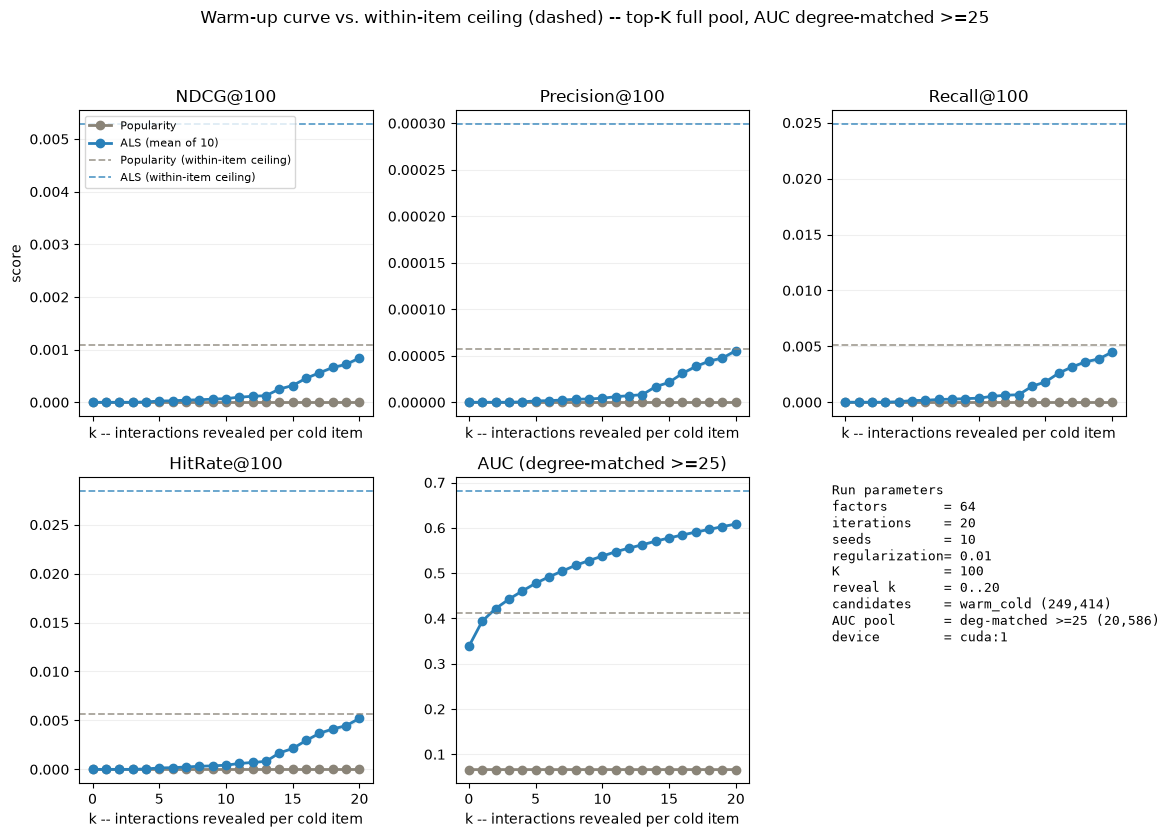

In [9]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS)):
    als_mean = np.array(als_curve[metric]["mean"])
    als_std = np.array(als_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    if RUN_POP:
        ax.plot(K_LEVELS, pop_curve[metric]["mean"], marker="o", markersize=6, linewidth=2,
                color="#8A8478", label=show_label("Popularity"))
    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    if RUN_POP:
        ax.axhline(pop_ref["mean"][metric], color="#8A8478", linestyle="--", linewidth=1.3, alpha=0.75,
                   label=show_label("Popularity (within-item ceiling)"))
    ax.axhline(als_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))

    ax.set_title("AUC (degree-matched >=25)" if metric == "AUC" else f"{metric}@{K}")
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", f"deg-matched >=25 ({len(seed_models[0]._auc_candidate_ids):,})"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Warm-up curve vs. within-item ceiling (dashed) -- top-K full pool, AUC degree-matched >=25", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_a.png", dpi=120, bbox_inches="tight")
print("Saved Mode A warm-up curve to warmup_curve_mode_a.png")

## 9b. Head / torso / tail breakdown (secondary)

Splits the cold items into equal-count degree terciles (by TOTAL interactions) and reports, at the
within-item ceiling per bucket: the **degree range** each bucket spans, **HitRate@K** (fraction of
that bucket's held-out interactions retrieved into top-K) and **NDCG@K** (its rank-discounted
version — are head items not just *hit* more often but ranked *higher*?). The mainstream,
low-friction way to surface popularity / long-tail effects (Steck 2011 popularity-stratified
evaluation; the head/torso/tail breakdown standard in long-tail recsys), complementary to the
degree-matched AUC. Reading it: even fully warm, do low-degree (tail) cold items retrieve worse
than head? Buckets are equal-count in items, so each holds ~n_cold/3 items and ~5x that many
held-out interactions (the fixed last-5 test). The **Popularity floor** is shown per bucket
alongside ALS, so you can see whether ALS's edge over popularity is uniform across degree or (as
expected) concentrated in the head, where raw counts are high.

Head/torso/tail at the within-item ceiling (equal-count degree terciles, K=100):
  bucket    degree range  median  items  ALS HitR  ALS NDCG  Pop HitR  Pop NDCG
  tail             25-32      27    909    0.0095    0.0018    0.0000    0.0000
  torso            32-49      38    909    0.0098    0.0018    0.0000    0.0000
  head           49-1759      75    909    0.0621    0.0130    0.0156    0.0032
Saved head/torso/tail breakdown to warmup_tail_breakdown.png
CPU times: user 4.26 s, sys: 73.1 ms, total: 4.33 s
Wall time: 2.39 s


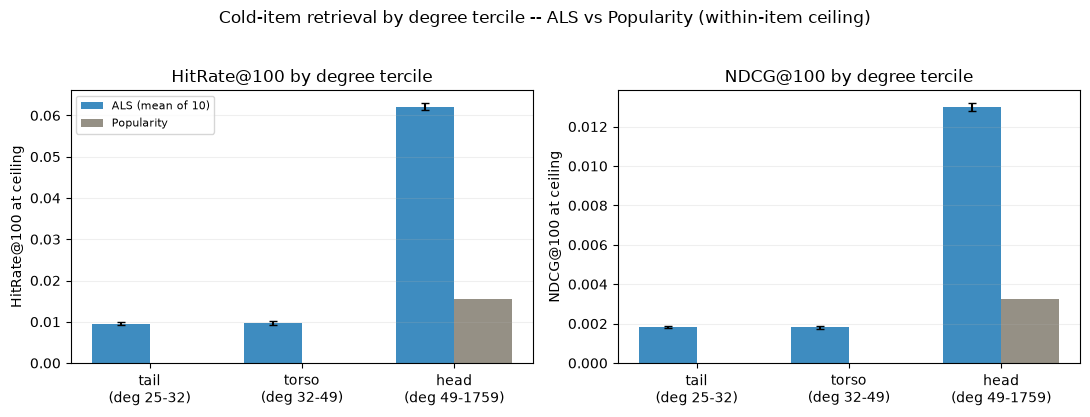

In [10]:
%%time
item_bucket, bucket_labels, bucket_info = ev.cold_item_degree_buckets(dataset, n_buckets=3)
strata = ev.ceiling_metrics_by_bucket(seed_models, dataset, item_bucket, K=K, n_buckets=3)
# Popularity floor per bucket -- PopularityModel has fold_in_ceiling/recommend, so the same call
# works. Reveals whether ALS's edge over popularity is uniform across degree or head-concentrated.
pop_strata = ev.ceiling_metrics_by_bucket([pop_model], dataset, item_bucket, K=K, n_buckets=3) if RUN_POP else None

print(f"Head/torso/tail at the within-item ceiling (equal-count degree terciles, K={K}):")
hdr = f"  {'bucket':<7}{'degree range':>15}{'median':>8}{'items':>7}{'ALS HitR':>10}{'ALS NDCG':>10}"
if RUN_POP:
    hdr += f"{'Pop HitR':>10}{'Pop NDCG':>10}"
print(hdr)
for b, lab in enumerate(bucket_labels):
    bi, s = bucket_info[b], strata[b]
    rng = f"{bi['deg_min']}-{bi['deg_max']}"
    row = f"  {lab:<7}{rng:>15}{bi['deg_median']:>8}{bi['n_items']:>7,}{s['hitrate']:>10.4f}{s['ndcg']:>10.4f}"
    if RUN_POP:
        ps = pop_strata[b]
        row += f"{ps['hitrate']:>10.4f}{ps['ndcg']:>10.4f}"
    print(row)

# Two panels (HitRate, NDCG); ALS vs Popularity per degree tercile.
fig, (axh, axn) = plt.subplots(1, 2, figsize=(11, 4))
xs = np.arange(len(bucket_labels)); w = 0.38
xtl = [f"{bucket_labels[b]}\n(deg {bucket_info[b]['deg_min']}-{bucket_info[b]['deg_max']})"
       for b in range(len(bucket_labels))]
for ax, metric, mlabel in [(axh, "hitrate", f"HitRate@{K}"), (axn, "ndcg", f"NDCG@{K}")]:
    ax.bar(xs - (w / 2 if RUN_POP else 0), [strata[b][metric] for b in range(len(bucket_labels))], w,
           yerr=[strata[b][metric + "_std"] for b in range(len(bucket_labels))], capsize=3,
           color="#2980b9", alpha=0.9, label=f"ALS (mean of {N_SEEDS})")
    if RUN_POP:
        ax.bar(xs + w / 2, [pop_strata[b][metric] for b in range(len(bucket_labels))], w,
               color="#8A8478", alpha=0.9, label="Popularity")
    ax.set_xticks(xs); ax.set_xticklabels(xtl)
    ax.set_ylabel(f"{mlabel} at ceiling"); ax.set_title(f"{mlabel} by degree tercile")
    ax.grid(axis="y", alpha=0.2)
axh.legend(fontsize=8)
fig.suptitle("Cold-item retrieval by degree tercile -- ALS vs Popularity (within-item ceiling)", y=1.03)
plt.tight_layout()
plt.savefig("warmup_tail_breakdown.png", dpi=120, bbox_inches="tight")
print("Saved head/torso/tail breakdown to warmup_tail_breakdown.png")

# Log the head/torso/tail ceiling breakdown to the (still-open) ALS run as summary values.
for b, lab in enumerate(bucket_labels):
    als_run.summary[f"tail/{lab}/HitRate"] = strata[b]["hitrate"]
    als_run.summary[f"tail/{lab}/NDCG"] = strata[b]["ndcg"]

## 10. Warm-up curve — item-to-user view (Mode B)

Section 9 asks, from a *user's* perspective: does this cold item surface in my personal
top-K? This asks the same question from the opposite direction — for a single cold item, rank
every user by predicted affinity, and check whether the users known (from the reserved test
set) to actually be interested in it land near the top of *its* top-K. Same fold-in factors as
Section 7/9, just a transposed ranking axis — see `eval.sweep_item_to_user_gpu`.

**Why Popularity has no line here, and Activity does.** Popularity assigns every user an
identical score for a given item — no per-user signal to rank users *by*. But the *principle*
behind it — rank by observed volume, no personalization — has a direct dual on this axis:
**global user activity** (`pop.ActivityModel`), ranking users by their total interaction count
in `ref_train`, frozen exactly like `user_factors` are treated everywhere else.

**Why `K=10` here, not Section 9's `K=100`.** Mode B's candidate pool is the user population
(millions), not the warm-item catalog — each cold item is ranked over users. A small K keeps the
metric discriminating rather than saturating. (The exact K was tuned on the earlier small-scale
proof-of-concept; revisit it for Amazon Books when Mode B is run on GPU.)

**Downsampled Test Set — now an identity.** Recall@K is capped at `K/r_i` and Precision@K at
`r_i/K` for an item with `r_i` reserved test users. Under the OLD split (test = everything after
reveal 20), `r_i` varied widely, so `eval.build_mode_b_context` drew a fixed 5-user sample per item
for comparability. The leave-last-5-out split makes `r_i` **exactly 5 for every cold item**, so the
downsample-to-5 is now a no-op (it selects all 5) — the comparability fix is baked into the split.
AUC stays on the full (now 5-user) reserved test set, over the full user population (not
degree-matched — Mode B's floor is the Activity model, which stays as the user-degree baseline).

**`eval.mode_b_ceiling`** reports what a hypothetically perfect ranking would score on each
metric — NDCG/HitRate/AUC are trivially 1.0; Precision@K and Recall@K actually depend on `r_i`
and are the two worth reading against their ceiling.

In [11]:
%%time
DOWNSAMPLE_SIZE = 5
K_MODE_B = 10
METRICS_MODE_B = ev.METRICS_MODE_B  # ["NDCG", "Precision", "Recall", "HitRate", "AUC"]

mode_b_ctx = ev.build_mode_b_context(dataset, downsample_size=DOWNSAMPLE_SIZE, seed=42)
activity_model = pop.ActivityModel().fit(dataset.ref_train)

print(f"Downsampled test set: {mode_b_ctx.downsampled_test_matrix.nnz:,} interactions across "
      f"{len(dataset.cold_item_ids)} items ({DOWNSAMPLE_SIZE} per item, exactly).")

ceiling = ev.mode_b_ceiling(dataset, mode_b_ctx, K=K_MODE_B)
print(f"Mode B ceiling at K={K_MODE_B} (perfect ranking, fixed across all k): "
      + "   ".join(f"{m}={ceiling[m]:.4f}" for m in METRICS_MODE_B))

# GPU Mode B: scores only the cold-item columns (no dense score matrix), so it runs at Amazon scale
# (a dense-score-matrix Mode B would not fit here). AUC is the full-user-population average-rank AUC
# (gpu_retrieval.mode_b_auc) -- the non-saturating companion to the four Downsampled Test Set metrics.
als_b_curve, n_eval_b_per_k = ev.sweep_item_to_user_gpu(seed_models, dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)

# Within-item ceiling (Mode B analog of Section 6): each cold item folded in with ALL its pre-test
# interactions, ranking users, on the same last-5 test -- the dashed line the ALS curve warms up
# toward. (Activity is k-invariant, so its "ceiling" is just its flat curve -- no separate line.)
mode_b_ref = ev.mode_b_reference(seed_models, dataset, mode_b_ctx, K=K_MODE_B)
print("Mode B within-item ceiling (ALS, all pre-test history folded in): "
      + "   ".join(f"{m}={mode_b_ref['mean'][m]:.4f}" for m in METRICS_MODE_B))

# Activity floor: deterministic, so cache it. Its AUC (over all users, same basis as ALS Mode B AUC)
# comes from ev.activity_auc_curve -- the sweep leaves Activity's AUC NaN (it ranks by activity, not
# factors), so we fill it here. Keyed by K_MODE_B, K_LEVELS, and the downsample size.
def _activity_b_curve():
    c = ev.sweep_item_to_user_gpu([activity_model], dataset, mode_b_ctx, K_LEVELS, K=K_MODE_B)[0]
    c["AUC"] = ev.activity_auc_curve(activity_model, dataset, K_LEVELS, device=DEVICE)
    return c
activity_b_curve = cache_pickle("activity_b_curve", _activity_b_curve,
                                params=(K_MODE_B, tuple(K_LEVELS), DOWNSAMPLE_SIZE, "5core"))

# --- Weights & Biases: open the Activity run; als_run (from Section 9) also logs its Mode B metrics ---
activity_run = wandb.init(entity=WANDB_ENTITY_NAME, project=WANDB_PROJECT_NAME, name=f"activity-{RUN_TAG}",
                          mode=WANDB_MODE, reinit="create_new")
als_run.define_metric("mode_b/*", step_metric="k")
activity_run.define_metric("mode_b/*", step_metric="k")

print("\nItem-to-user (Mode B) sweep:")
for i, k in enumerate(K_LEVELS):
    print(f"k={k:>2}  eval items={n_eval_b_per_k[i]:>4}  "
          + "  ".join(f"{m}: ALS={als_b_curve[m]['mean'][i]:.4f} "
                       f"Activity={activity_b_curve[m]['mean'][i]:.4f}" for m in METRICS_MODE_B))

    # Log this reveal level to W&B (mode_b/* against step metric k)
    als_run.log({"k": k, **{f"mode_b/{m}": als_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})
    activity_run.log({"k": k, **{f"mode_b/{m}": activity_b_curve[m]["mean"][i] for m in METRICS_MODE_B}})

# Finish both runs -- als_run has now logged Mode A + Mode B.
als_run.finish()
activity_run.finish()

Downsampled test set: 13,635 interactions across 2727 items (5 per item, exactly).
Mode B ceiling at K=10 (perfect ranking, fixed across all k): NDCG=1.0000   Precision=0.5000   Recall=1.0000   HitRate=1.0000   AUC=1.0000
[sweep_item_to_user_gpu] setup=0.1s  foldin=6.4s  score=7.6s  metric=3.7s  auc=49.7s  total=67.5s
Mode B within-item ceiling (ALS, all pre-test history folded in): NDCG=0.0049   Precision=0.0028   Recall=0.0055   HitRate=0.0250   AUC=0.7469


wandb: ERROR The nbformat package was not found. It is required to save notebook history.



Item-to-user (Mode B) sweep:
k= 0  eval items=2727  NDCG: ALS=0.0001 Activity=0.0006  Precision: ALS=0.0000 Activity=0.0004  Recall: ALS=0.0001 Activity=0.0007  HitRate: ALS=0.0004 Activity=0.0037  AUC: ALS=0.5000 Activity=0.6743
k= 1  eval items=2727  NDCG: ALS=0.0024 Activity=0.0006  Precision: ALS=0.0014 Activity=0.0004  Recall: ALS=0.0029 Activity=0.0007  HitRate: ALS=0.0135 Activity=0.0037  AUC: ALS=0.6633 Activity=0.6743
k= 2  eval items=2727  NDCG: ALS=0.0029 Activity=0.0006  Precision: ALS=0.0017 Activity=0.0004  Recall: ALS=0.0034 Activity=0.0007  HitRate: ALS=0.0158 Activity=0.0037  AUC: ALS=0.6727 Activity=0.6743
k= 3  eval items=2727  NDCG: ALS=0.0028 Activity=0.0006  Precision: ALS=0.0017 Activity=0.0004  Recall: ALS=0.0035 Activity=0.0007  HitRate: ALS=0.0168 Activity=0.0037  AUC: ALS=0.6814 Activity=0.6743
k= 4  eval items=2727  NDCG: ALS=0.0030 Activity=0.0006  Precision: ALS=0.0019 Activity=0.0004  Recall: ALS=0.0037 Activity=0.0007  HitRate: ALS=0.0180 Activity=0.003

k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█
mode_a/AUC,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
mode_a/HitRate,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_a/NDCG,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▆▇█
mode_a/Precision,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_a/Recall,▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▅▆▇▇█
mode_b/AUC,▁▆▆▇▇▇▇▇▇▇▇██████████
mode_b/HitRate,▁▆▇▇▇▇▇▇▇▇▇██████████
mode_b/NDCG,▁▅▆▆▆▆▆▆▆▆▇▇▇▇▇██████
mode_b/Precision,▁▅▆▇▇▇▇▇▇▇▇▇██▇██████
+1,...


k,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
mode_b/AUC,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▆▇▇▇██
mode_b/HitRate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_b/NDCG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████
mode_b/Precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mode_b/Recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
k,20
mode_b/AUC,0.67428
mode_b/HitRate,0.00367
mode_b/NDCG,0.00065
mode_b/Precision,0.00037


CPU times: user 1min 40s, sys: 2.26 s, total: 1min 43s
Wall time: 1min 17s


Saved Mode B warm-up curve to warmup_curve_mode_b.png
CPU times: user 498 ms, sys: 1.61 ms, total: 500 ms
Wall time: 495 ms


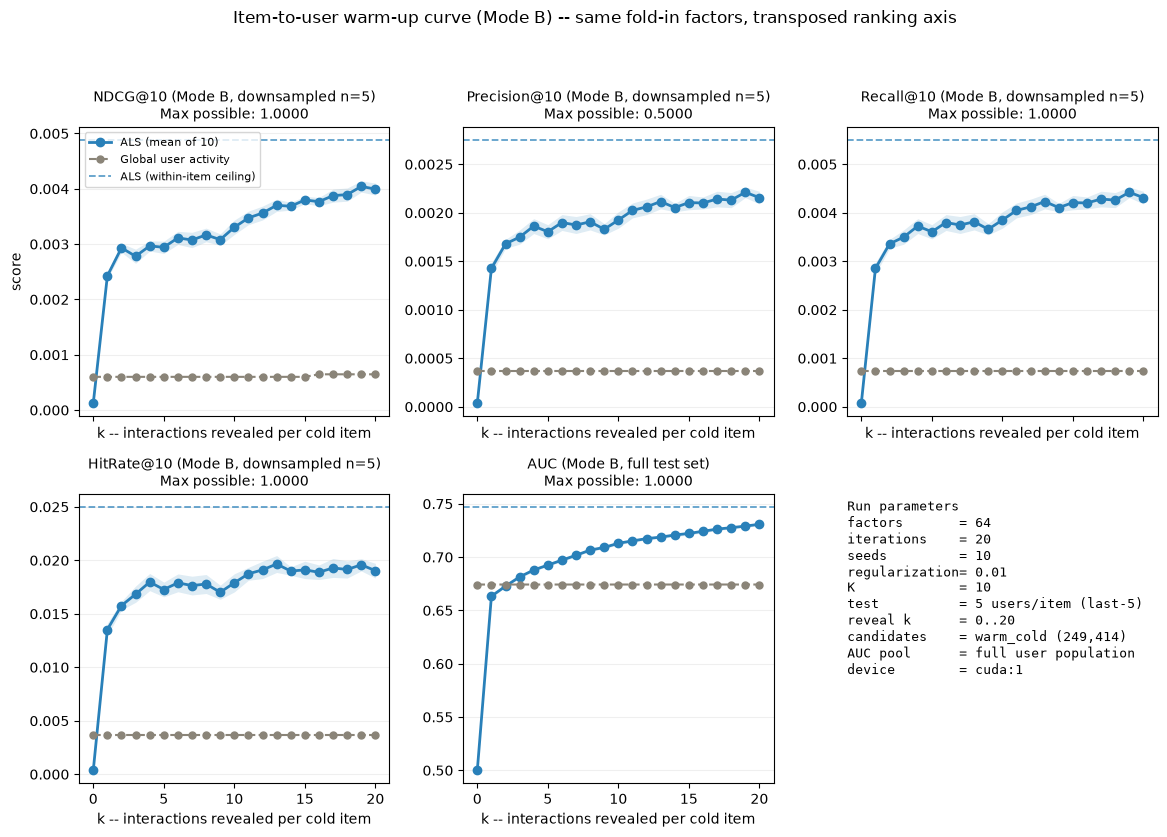

In [12]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex='col')
axes = axes.flatten()

for i, (ax, metric) in enumerate(zip(axes, METRICS_MODE_B)):
    als_mean = np.array(als_b_curve[metric]["mean"])
    als_std = np.array(als_b_curve[metric]["std"])
    show_label = (lambda text: text) if i == 0 else (lambda text: None)

    ax.plot(K_LEVELS, als_mean, marker="o", markersize=6, linewidth=2,
            color="#2980b9", label=show_label(f"ALS (mean of {N_SEEDS})"))
    ax.fill_between(K_LEVELS, als_mean - als_std, als_mean + als_std, color="#2980b9", alpha=0.15, linewidth=0)
    ax.plot(K_LEVELS, activity_b_curve[metric]["mean"], marker="o", markersize=5, linewidth=1.5,
            linestyle="--", color="#8A8478", label=show_label("Global user activity"))
    ax.axhline(mode_b_ref["mean"][metric], color="#2980b9", linestyle="--", linewidth=1.3, alpha=0.75,
               label=show_label("ALS (within-item ceiling)"))

    title_line1 = ("AUC (Mode B, full test set)" if metric == "AUC"
                   else f"{metric}@{K_MODE_B} (Mode B, downsampled n={DOWNSAMPLE_SIZE})")
    ax.set_title(f"{title_line1}\nMax possible: {ceiling[metric]:.4f}", fontsize=10)
    ax.set_xlabel("k -- interactions revealed per cold item")
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8, loc="upper left")

# Run-parameters panel in the empty 6th subplot (5 metrics -> axes[5] is free).
_params = [("factors", ALS_PARAMS["factors"]), ("iterations", ALS_PARAMS["iterations"]),
           ("seeds", N_SEEDS), ("regularization", ALS_PARAMS["regularization"]), ("K", K_MODE_B),
           ("test", f"{DOWNSAMPLE_SIZE} users/item (last-5)"),
           ("reveal k", f"{K_LEVELS[0]}..{K_LEVELS[-1]}"),
           ("candidates", f"warm_cold ({len(seed_models[0]._candidate_ids):,})"),
           ("AUC pool", "full user population"),
           ("device", DEVICE)]
axes[5].axis("off")
axes[5].text(0.0, 0.98, "Run parameters\n" + "\n".join(f"{k:<14}= {v}" for k, v in _params),
             family="monospace", fontsize=9, va="top", transform=axes[5].transAxes)

fig.suptitle("Item-to-user warm-up curve (Mode B) -- same fold-in factors, transposed ranking axis", y=1.04)
plt.tight_layout()
plt.savefig("warmup_curve_mode_b.png", dpi=120, bbox_inches="tight")
print("Saved Mode B warm-up curve to warmup_curve_mode_b.png")

## 11. Persist results

The warm-up curves and warm-item reference are the deliverable of this run, but they otherwise live
only in cell outputs / kernel memory -- clearing outputs or restarting the kernel loses them (only
the PNGs and the Popularity caches survive). This dumps everything -- config + every curve +
reference + n_eval + Mode B ceiling -- to a timestamped pickle (exact, for re-plotting) and JSON
(human-readable) under `../results/`, so the final run is fully recoverable. To copy the results off
WSL afterwards: `cp ~/699-gpu-bench/results/* /mnt/c/699-gpu-bench-results/`.

In [13]:
%%time
import json, pickle, datetime

results = {
    "config": {
        "ALS_PARAMS": ALS_PARAMS, "N_SEEDS": N_SEEDS, "K": K, "K_LEVELS": K_LEVELS,
        "K_MODE_B": K_MODE_B, "DOWNSAMPLE_SIZE": DOWNSAMPLE_SIZE, "DEVICE": DEVICE, "RUN_POP": RUN_POP,
        "n_users": int(dataset.n_users), "n_items": int(dataset.n_items),
        "n_cold_items": int(len(dataset.cold_item_ids)),
        "test_per_cold_item": int(dataset.test_matrix.nnz / max(len(dataset.cold_item_ids), 1)),
        "auc_min_degree": 25,   # degree-matched AUC pool threshold (reserve degree-matching for AUC)
        "ref_train_nnz": int(dataset.ref_train.nnz), "ref_test_nnz": int(dataset.ref_test.nnz),
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    },
    # "reference" is now the WITHIN-ITEM ceiling (cold items folded in with all pre-test history on the
    # last-5 test), not the old cross-population warm-item reference.
    "reference": {"als": als_ref, "pop": pop_ref},
    "mode_a": {"als_curve": als_curve, "pop_curve": pop_curve, "n_eval_per_k": n_eval_per_k,
               "strata": strata, "pop_strata": pop_strata,
               "bucket_labels": bucket_labels, "bucket_info": bucket_info},
    "mode_b": {"als_curve": als_b_curve, "activity_curve": activity_b_curve,
               "n_eval_per_k": n_eval_b_per_k, "ceiling": ceiling, "within_item_ceiling": mode_b_ref},
}

os.makedirs("../results", exist_ok=True)
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base = f"../results/baseline_cf_{stamp}"
with open(base + ".pkl", "wb") as f:
    pickle.dump(results, f)
with open(base + ".json", "w") as f:
    json.dump(results, f, indent=2, default=lambda o: float(o) if hasattr(o, "__float__") else str(o))
print(f"Saved results to {base}.pkl and {base}.json")
print(f"  seeds={N_SEEDS}  iters={ALS_PARAMS['iterations']}  factors={ALS_PARAMS['factors']}  "
      f"K={K}  K_LEVELS={K_LEVELS[0]}..{K_LEVELS[-1]}  device={DEVICE}")

# ---- Consolidated results recap (headline top-K first; AUC is degree-matched, reported last) ----
print("\n" + "=" * 78)
print("RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)")
print("=" * 78)
lastk = len(K_LEVELS) - 1
print(f"\nMode A -- user-centric (K={K}):")
print(f"  {'metric':<12}{'Pop k=0':>10}{'ALS k=0':>10}{'Pop k=20':>11}{'ALS k=20':>11}"
      f"{'Pop ceil':>11}{'ALS ceil':>11}")
for m in METRICS:
    row = (f"  {m:<12}"
           f"{(pop_curve[m]['mean'][0] if RUN_POP else float('nan')):>10.4f}"
           f"{als_curve[m]['mean'][0]:>10.4f}"
           f"{(pop_curve[m]['mean'][lastk] if RUN_POP else float('nan')):>11.4f}"
           f"{als_curve[m]['mean'][lastk]:>11.4f}"
           f"{(pop_ref['mean'][m] if RUN_POP else float('nan')):>11.4f}"
           f"{als_ref['mean'][m]:>11.4f}")
    print(row)

print(f"\nMode A tail breakdown -- within-item ceiling by degree tercile (K={K}):")
for b in range(len(bucket_labels)):
    bi, s = bucket_info[b], strata[b]
    print(f"  {bucket_labels[b]:<6} deg {bi['deg_min']}-{bi['deg_max']} (med {bi['deg_median']}, "
          f"{bi['n_items']:,} items):  HitRate={s['hitrate']:.4f}  NDCG={s['ndcg']:.4f}")

print(f"\nMode B -- item-to-user (K={K_MODE_B}; AUC full user population):")
print(f"  {'metric':<12}{'Act k=20':>11}{'ALS k=20':>11}{'ALS ceil':>11}{'max':>9}")
for m in METRICS_MODE_B:
    print(f"  {m:<12}{activity_b_curve[m]['mean'][lastk]:>11.4f}{als_b_curve[m]['mean'][lastk]:>11.4f}"
          f"{mode_b_ref['mean'][m]:>11.4f}{ceiling[m]:>9.4f}")
print("=" * 78)

Saved results to ../results/baseline_cf_20260726_110539.pkl and ../results/baseline_cf_20260726_110539.json
  seeds=10  iters=20  factors=64  K=100  K_LEVELS=0..20  device=cuda:1

RESULTS RECAP  (top-K on the full warm_cold pool; AUC on the degree-matched >=25 pool)

Mode A -- user-centric (K=100):
  metric         Pop k=0   ALS k=0   Pop k=20   ALS k=20   Pop ceil   ALS ceil
  NDCG            0.0000    0.0000     0.0000     0.0008     0.0011     0.0053
  Precision       0.0000    0.0000     0.0000     0.0001     0.0001     0.0003
  Recall          0.0000    0.0000     0.0000     0.0045     0.0051     0.0249
  HitRate         0.0000    0.0000     0.0000     0.0052     0.0057     0.0284
  AUC             0.0662    0.3383     0.0662     0.6084     0.4115     0.6804

Mode A tail breakdown -- within-item ceiling by degree tercile (K=100):
  tail   deg 25-32 (med 27, 909 items):  HitRate=0.0095  NDCG=0.0018
  torso  deg 32-49 (med 38, 909 items):  HitRate=0.0098  NDCG=0.0018
  head   deg 49

## 12. Summary

- **Objective:** isolate the effect that a given retrieval method has on how quickly an item
  becomes recommendable as it accumulates interaction history — built so that future
  interventions (content embeddings, improved content embeddings, LLM-simulated interactions)
  can be slotted in and compared against this same baseline on equal footing.
- **The controlling principle:** user preferences are fit once (Section 5b, on `ref_train`)
  and reused identically everywhere in this notebook. Only the item's own representation
  changes as it accumulates revealed history.
- **Modularization:** the mechanism now lives in `load.py`/`pop.py`/`cf.py`/`eval.py` behind a
  shared `protocol.RetrievalModel` contract, so a future retrieval method plugs into the exact
  same `eval.sweep_mode_a_cached()`/`sweep_item_to_user_gpu()` calls used above — no new
  evaluation code required.